# Load existing DL/XGBoost models and evaluate score/strategy variants

This notebook is intentionally **load-only**: it does not fit or tune any model. It builds a unified prediction table from already generated artifacts for XGBoost, MLP, and the small FT-Transformer, then reuses the score-construction and backtest workflow.


In [1]:
# Cell 1: Imports, configuration, and paths

from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import torch
except ImportError as exc:
    raise ImportError("PyTorch is required to load the saved MLP checkpoints.") from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_SEED = 362559


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start, start.parent, start.parent.parent]
    for candidate in candidates:
        if (candidate / "Dataset").exists() or (candidate / "outputs").exists() or (candidate / "scripts").exists():
            return candidate
    return start.parent


REPO_ROOT = find_repo_root()
PANEL_PATH = REPO_ROOT / "Dataset/Processed/model_panel_full_features_with_splits.parquet"
BASELINE_PREDICTION_PATH = REPO_ROOT / "outputs/predictions/baseline_predictions_with_boosting.parquet"
FT_PREDICTION_PATH = REPO_ROOT / "outputs/predictions/ft_transformer_predictions.parquet"
TEMPORAL_PREDICTION_PATH = REPO_ROOT / "outputs/predictions/temporal_tabular_transformer_predictions.parquet"
MLP_CLASSIFIER_CHECKPOINT = REPO_ROOT / "outputs/models/deep_learning/mlp_model.pt"
MLP_REGRESSOR_CHECKPOINT = REPO_ROOT / "outputs/models/deep_learning/regression/mlp_regressor.pt"

PREDICTION_OUTPUT = REPO_ROOT / "outputs/predictions/dl_xgb_predictions.parquet"
TABLE_DIR = REPO_ROOT / "outputs/tables"
BACKTEST_DIR = REPO_ROOT / "outputs/backtests/dl_xgb_score_strategies"
FIGURE_DIR = BACKTEST_DIR / "figures"

for directory in [PREDICTION_OUTPUT.parent, TABLE_DIR, BACKTEST_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PREDICT_BATCH_SIZE = 8192
SPLITS = ["train", "validation", "test"]
KEY_COLUMNS = ["PERMNO", "MthCalDt"]
ID_COLUMNS = ["permno", "gvkey", "mthcaldt", "split"]
TARGET_COLUMNS = ["target_ret_1m", "target_quintile", "top_bottom_label"]

print("Repository root:", REPO_ROOT)
print("Device for MLP inference:", DEVICE)
print("Baseline/XGBoost predictions:", BASELINE_PREDICTION_PATH)
print("MLP classifier checkpoint:", MLP_CLASSIFIER_CHECKPOINT)
print("MLP regressor checkpoint:", MLP_REGRESSOR_CHECKPOINT)
print("FT predictions:", FT_PREDICTION_PATH)
print("Temporal Transformer predictions:", TEMPORAL_PREDICTION_PATH)


Repository root: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164
Device for MLP inference: cpu
Baseline/XGBoost predictions: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/baseline_predictions_with_boosting.parquet
MLP classifier checkpoint: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/models/deep_learning/mlp_model.pt
MLP regressor checkpoint: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/models/deep_learning/regression/mlp_regressor.pt
FT predictions: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/ft_transformer_predictions.parquet


In [2]:
# Cell 2: Artifact validation

required_artifacts = [
    PANEL_PATH,
    BASELINE_PREDICTION_PATH,
    FT_PREDICTION_PATH,
    TEMPORAL_PREDICTION_PATH,
    MLP_CLASSIFIER_CHECKPOINT,
    MLP_REGRESSOR_CHECKPOINT,
]
missing = [path for path in required_artifacts if not path.exists()]
if missing:
    missing_text = "\n".join(str(path) for path in missing)
    raise FileNotFoundError(f"Missing required pre-trained artifact(s):\n{missing_text}")

for path in required_artifacts:
    print(path.relative_to(REPO_ROOT))


Dataset/Processed/model_panel_full_features_with_splits.parquet
outputs/predictions/baseline_predictions_with_boosting.parquet
outputs/predictions/ft_transformer_predictions.parquet
outputs/models/deep_learning/mlp_model.pt
outputs/models/deep_learning/regression/mlp_regressor.pt


In [3]:
# Cell 3: Load panel rows needed for MLP inference

mlp_classifier_checkpoint = torch.load(MLP_CLASSIFIER_CHECKPOINT, map_location="cpu", weights_only=False)
mlp_regressor_checkpoint = torch.load(MLP_REGRESSOR_CHECKPOINT, map_location="cpu", weights_only=False)

classifier_features = list(mlp_classifier_checkpoint["feature_list"])
regressor_features = list(mlp_regressor_checkpoint["feature_list"])
if classifier_features != regressor_features:
    raise ValueError("MLP classifier and regressor checkpoints use different feature lists.")
feature_columns = classifier_features

load_columns = ID_COLUMNS + TARGET_COLUMNS + feature_columns
panel = pd.read_parquet(PANEL_PATH, columns=load_columns)
panel["mthcaldt"] = pd.to_datetime(panel["mthcaldt"], errors="raise")
panel["split"] = panel["split"].astype(str)
panel = panel.sort_values(["mthcaldt", "permno"]).reset_index(drop=True)

for feature in feature_columns:
    panel[feature] = pd.to_numeric(panel[feature], errors="coerce").astype("float32")
panel["target_ret_1m"] = pd.to_numeric(panel["target_ret_1m"], errors="raise").astype("float32")
panel["top_bottom_label"] = panel["top_bottom_label"].astype("int64")

if panel.duplicated(["permno", "mthcaldt"]).any():
    raise ValueError("Duplicate permno-mthcaldt rows found in modeling panel.")

split_summary = (
    panel.groupby("split")
    .agg(rows=("permno", "size"), first_month=("mthcaldt", "min"), last_month=("mthcaldt", "max"), stocks=("permno", "nunique"))
    .reindex(SPLITS)
)

print("Feature count:", len(feature_columns))
display(split_summary)


Feature count: 98


,rows,first_month,last_month,stocks
split,,,,
train,1834902,1989-12-29,2010-11-30,19469
validation,405264,2010-12-31,2015-11-30,9129
test,868926,2015-12-31,2024-10-31,14523


In [4]:
# Cell 4: Inference helpers for saved MLP checkpoints

class MLPClassifier(torch.nn.Module):
    """Checkpoint-compatible architecture from scripts/deep_learning/mlp_common.py."""

    def __init__(self, input_dim: int, dropout: float = 0.25) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class MLPRegressor(torch.nn.Module):
    """Checkpoint-compatible architecture from scripts/deep_learning/train_mlp_regressor.py."""

    def __init__(self, input_dim: int, dropout: float = 0.25) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


def transform_features_from_checkpoint(data: pd.DataFrame, checkpoint: dict[str, Any]) -> np.ndarray:
    feature_list = list(checkpoint["feature_list"])
    x = data[feature_list].to_numpy(dtype="float32", copy=True)
    medians = np.asarray(checkpoint["imputer_statistics"], dtype="float32")
    means = np.asarray(checkpoint["scaler_mean"], dtype="float32")
    scales = np.asarray(checkpoint["scaler_scale"], dtype="float32")
    row_idx, col_idx = np.where(np.isnan(x))
    if len(row_idx):
        x[row_idx, col_idx] = medians[col_idx]
    return ((x - means) / scales).astype("float32")


def predict_mlp_classifier(checkpoint: dict[str, Any], data: pd.DataFrame) -> np.ndarray:
    model = MLPClassifier(input_dim=int(checkpoint["input_dim"]), dropout=float(checkpoint.get("dropout", 0.25))).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    x = transform_features_from_checkpoint(data, checkpoint)
    batches = []
    with torch.no_grad():
        for start in range(0, len(x), PREDICT_BATCH_SIZE):
            batch = torch.from_numpy(x[start : start + PREDICT_BATCH_SIZE]).to(DEVICE)
            batches.append(torch.softmax(model(batch), dim=1).detach().cpu().numpy())
    return np.concatenate(batches, axis=0).astype("float64")


def predict_mlp_regressor(checkpoint: dict[str, Any], data: pd.DataFrame) -> np.ndarray:
    model = MLPRegressor(input_dim=int(checkpoint["input_dim"]), dropout=float(checkpoint.get("dropout", 0.25))).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    x = transform_features_from_checkpoint(data, checkpoint)
    batches = []
    with torch.no_grad():
        for start in range(0, len(x), PREDICT_BATCH_SIZE):
            batch = torch.from_numpy(x[start : start + PREDICT_BATCH_SIZE]).to(DEVICE)
            batches.append(model(batch).detach().cpu().numpy())
    return np.concatenate(batches, axis=0).astype("float64")


def percentile_score_by_month(months: pd.Series, predictions: np.ndarray) -> np.ndarray:
    frame = pd.DataFrame({"month": pd.to_datetime(months), "prediction": np.asarray(predictions, dtype="float64")})
    return frame.groupby("month", sort=False, observed=True)["prediction"].rank(method="average", pct=True).to_numpy(dtype="float64")


In [5]:
# Cell 5: Rank IC utilities used for diagnostics


def monthly_rank_ic_for_arrays(months: pd.Series | np.ndarray, y_true: np.ndarray, score: np.ndarray) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "month": pd.to_datetime(np.asarray(months)),
            "target_ret_1m": np.asarray(y_true, dtype="float64"),
            "score": np.asarray(score, dtype="float64"),
        }
    ).dropna()
    rows = []
    for month, part in frame.groupby("month", sort=True):
        if len(part) < 5 or part["score"].nunique() <= 1 or part["target_ret_1m"].nunique() <= 1:
            ic = np.nan
        else:
            ic = part["score"].corr(part["target_ret_1m"], method="spearman")
        rows.append({"month": month, "rank_ic": ic, "n_stocks": len(part)})
    return pd.DataFrame(rows)


def mean_monthly_rank_ic(months: pd.Series | np.ndarray, y_true: np.ndarray, score: np.ndarray) -> float:
    monthly = monthly_rank_ic_for_arrays(months, y_true, score)
    values = monthly["rank_ic"].dropna()
    if values.empty:
        return np.nan
    return float(values.mean())


In [6]:
# Cell 6: Generate MLP predictions from saved checkpoints only

predictions = panel[["permno", "gvkey", "mthcaldt", "split", "target_ret_1m", "target_quintile", "top_bottom_label"]].copy()
predictions = predictions.rename(columns={"permno": "PERMNO", "mthcaldt": "MthCalDt"})

print("Running MLP classifier inference from saved checkpoint...")
mlp_probs = predict_mlp_classifier(mlp_classifier_checkpoint, panel)
predictions["prob_mlp_bottom"] = mlp_probs[:, 0]
predictions["prob_mlp_middle"] = mlp_probs[:, 1]
predictions["prob_mlp_top"] = mlp_probs[:, 2]
predictions["prediction_mlp_classifier_score"] = mlp_probs[:, 2] - mlp_probs[:, 0]
predictions["prediction_mlp_score"] = predictions["prediction_mlp_classifier_score"]
class_means = np.asarray(mlp_classifier_checkpoint["class_means"], dtype="float64")
predictions["prediction_mlp_er_train_score"] = mlp_probs @ class_means

print("Running MLP regressor inference from saved checkpoint...")
mlp_reg_pred = predict_mlp_regressor(mlp_regressor_checkpoint, panel)
predictions["prediction_mlp_regressor"] = mlp_reg_pred
predictions["prediction_mlp_reg_return"] = mlp_reg_pred
predictions["score_mlp_reg_er"] = mlp_reg_pred
predictions["score_mlp_reg_cls"] = percentile_score_by_month(predictions["MthCalDt"], mlp_reg_pred)

mlp_summary = pd.DataFrame(
    [
        {
            "model": "mlp_classifier",
            "model_family": "MLP",
            "task": "classification",
            "source": str(MLP_CLASSIFIER_CHECKPOINT.relative_to(REPO_ROOT)),
            "best_epoch": mlp_classifier_checkpoint.get("best_epoch"),
            "best_validation_monthly_rank_ic": mlp_classifier_checkpoint.get("best_validation_ic_cls"),
        },
        {
            "model": "mlp_regressor",
            "model_family": "MLP",
            "task": "regression",
            "source": str(MLP_REGRESSOR_CHECKPOINT.relative_to(REPO_ROOT)),
            "best_epoch": mlp_regressor_checkpoint.get("best_epoch"),
            "best_validation_monthly_rank_ic": mlp_regressor_checkpoint.get("best_validation_ic_cls"),
        },
    ]
)
mlp_summary


Running MLP classifier inference from saved checkpoint...
Running MLP regressor inference from saved checkpoint...


,model,model_family,task,source,best_epoch,best_validation_monthly_rank_ic
0,mlp_classifier,MLP,classification,outputs/models/deep_learning/mlp_model.pt,1,0.073564
1,mlp_regressor,MLP,regression,outputs/models/deep_learning/regression/mlp_re...,3,0.017677


In [7]:
# Cell 7: Merge existing XGBoost and FT-Transformer prediction artifacts

xgb_predictions = pd.read_parquet(BASELINE_PREDICTION_PATH)
xgb_predictions["MthCalDt"] = pd.to_datetime(xgb_predictions["MthCalDt"], errors="raise")
xgb_columns = KEY_COLUMNS + [
    "prediction_gradient_boosting_reg",
    "prediction_gb_classifier_score",
    "prob_gb_bottom",
    "prob_gb_middle",
    "prob_gb_top",
]
missing_xgb = [col for col in xgb_columns if col not in xgb_predictions.columns]
if missing_xgb:
    raise ValueError(f"Missing XGBoost prediction columns: {missing_xgb}")
xgb_predictions = xgb_predictions[xgb_columns].rename(
    columns={
        "prediction_gradient_boosting_reg": "prediction_xgb_regressor",
        "prediction_gb_classifier_score": "prediction_xgb_classifier_score",
        "prob_gb_bottom": "prob_xgb_bottom",
        "prob_gb_middle": "prob_xgb_middle",
        "prob_gb_top": "prob_xgb_top",
    }
)

ft_predictions = pd.read_parquet(FT_PREDICTION_PATH)
ft_predictions["MthCalDt"] = pd.to_datetime(ft_predictions["MthCalDt"], errors="raise")
ft_columns = KEY_COLUMNS + [
    "prediction_ft_classifier_score",
    "prediction_ft_er_train_score",
    "prob_ft_bottom",
    "prob_ft_middle",
    "prob_ft_top",
]
missing_ft = [col for col in ft_columns if col not in ft_predictions.columns]
if missing_ft:
    raise ValueError(f"Missing FT prediction columns: {missing_ft}")
ft_predictions = ft_predictions[ft_columns]

predictions = predictions.merge(xgb_predictions, on=KEY_COLUMNS, how="left", validate="one_to_one")
predictions = predictions.merge(ft_predictions, on=KEY_COLUMNS, how="left", validate="one_to_one")

artifact_summary = pd.concat(
    [
        mlp_summary,
        pd.DataFrame(
            [
                {
                    "model": "xgb_regressor",
                    "model_family": "XGBoost",
                    "task": "regression",
                    "source": str(BASELINE_PREDICTION_PATH.relative_to(REPO_ROOT)),
                },
                {
                    "model": "xgb_classifier",
                    "model_family": "XGBoost",
                    "task": "classification",
                    "source": str(BASELINE_PREDICTION_PATH.relative_to(REPO_ROOT)),
                },
                {
                    "model": "ft_classifier_small",
                    "model_family": "FTTransformer",
                    "task": "classification",
                    "source": str(FT_PREDICTION_PATH.relative_to(REPO_ROOT)),
                },
                {
                    "model": "temporal_transformer",
                    "model_family": "TemporalTransformer",
                    "task": "classification",
                    "source": str(TEMPORAL_PREDICTION_PATH.relative_to(REPO_ROOT)),
                },
            ]
        ),
    ],
    ignore_index=True,
)
artifact_summary.to_csv(TABLE_DIR / "dl_xgb_loaded_artifacts.csv", index=False)

coverage = predictions.groupby("split", observed=True).agg(
    rows=("PERMNO", "size"),
    xgb_reg_nonnull=("prediction_xgb_regressor", "count"),
    xgb_cls_nonnull=("prediction_xgb_classifier_score", "count"),
    mlp_reg_nonnull=("prediction_mlp_regressor", "count"),
    mlp_cls_nonnull=("prediction_mlp_classifier_score", "count"),
    ft_cls_nonnull=("prediction_ft_classifier_score", "count"),
)
display(artifact_summary)
display(coverage)


,model,model_family,task,source,best_epoch,best_validation_monthly_rank_ic
0,mlp_classifier,MLP,classification,outputs/models/deep_learning/mlp_model.pt,1.0,0.073564
1,mlp_regressor,MLP,regression,outputs/models/deep_learning/regression/mlp_re...,3.0,0.017677
2,xgb_regressor,XGBoost,regression,outputs/predictions/baseline_predictions_with_...,NaN,NaN
3,xgb_classifier,XGBoost,classification,outputs/predictions/baseline_predictions_with_...,NaN,NaN
4,ft_classifier_small,FTTransformer,classification,outputs/predictions/ft_transformer_predictions...,NaN,NaN


,rows,xgb_reg_nonnull,xgb_cls_nonnull,mlp_reg_nonnull,mlp_cls_nonnull,ft_cls_nonnull
split,,,,,,
test,868926,868926,868926,868926,868926,868926
train,1834902,1828568,1828568,1834902,1834902,1834902
validation,405264,405264,405264,405264,405264,405264


In [ ]:
# Cell 7b: Merge Temporal Tabular Transformer prediction artifact

temporal_predictions = pd.read_parquet(TEMPORAL_PREDICTION_PATH)
temporal_predictions["MthCalDt"] = pd.to_datetime(temporal_predictions["MthCalDt"], errors="raise")

temporal_predictions = temporal_predictions.rename(columns={
    "prob_temporal_tabular_bottom": "prob_temporal_bottom",
    "prob_temporal_tabular_middle": "prob_temporal_middle",
    "prob_temporal_tabular_top": "prob_temporal_top",
    "prediction_temporal_tabular_classifier_score": "prediction_temporal_classifier_score",
})

required_cols = [
    "PERMNO",
    "MthCalDt",
    "prob_temporal_bottom",
    "prob_temporal_middle",
    "prob_temporal_top",
    "prediction_temporal_classifier_score",
]

missing = [c for c in required_cols if c not in temporal_predictions.columns]
if missing:
    raise ValueError(f"Missing Temporal columns: {missing}")

temporal_predictions = temporal_predictions[required_cols]

predictions = predictions.merge(temporal_predictions, on=["PERMNO", "MthCalDt"], how="left", validate="one_to_one")


In [8]:
# Cell 8: Save unified load-only prediction file

if predictions.duplicated(["PERMNO", "MthCalDt"]).any():
    raise ValueError("Prediction output has duplicate PERMNO-MthCalDt rows.")

predictions.to_parquet(PREDICTION_OUTPUT, index=False)
print("Saved predictions to", PREDICTION_OUTPUT)
print(predictions.shape)
predictions.head()


Saved predictions to /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/dl_xgb_predictions.parquet
(3109092, 27)


,PERMNO,gvkey,MthCalDt,split,target_ret_1m,target_quintile,top_bottom_label,prob_mlp_bottom,prob_mlp_middle,prob_mlp_top,prediction_mlp_classifier_score,prediction_mlp_score,prediction_mlp_er_train_score,prediction_mlp_regressor,prediction_mlp_reg_return,score_mlp_reg_er,score_mlp_reg_cls,prediction_xgb_regressor,prediction_xgb_classifier_score,prob_xgb_bottom,prob_xgb_middle,prob_xgb_top,prediction_ft_classifier_score,prediction_ft_er_train_score,prob_ft_bottom,prob_ft_middle,prob_ft_top
0,10001,012994,1989-12-29,train,-0.018519,4,1,0.095564,0.761519,0.142918,0.047354,0.047354,0.017179,-0.016492,-0.016492,-0.016492,0.692453,NaN,NaN,NaN,NaN,NaN,0.051911,0.017584,0.082746,0.782596,0.134657
1,10002,019049,1989-12-29,train,0.020408,4,1,0.104136,0.794002,0.101863,-0.002273,-0.002273,0.006173,-0.017973,-0.017973,-0.017973,0.600568,NaN,NaN,NaN,NaN,NaN,0.012230,0.010179,0.117302,0.753167,0.129532
2,10003,016950,1989-12-29,train,-0.088235,2,1,0.303891,0.454865,0.241244,-0.062647,-0.062647,0.002319,-0.010639,-0.010639,-0.010639,0.895800,NaN,NaN,NaN,NaN,NaN,-0.103405,-0.004282,0.359351,0.384703,0.255946
3,10005,012087,1989-12-29,train,0.000000,4,1,0.299282,0.460377,0.240341,-0.058942,-0.058942,0.002940,-0.025459,-0.025459,-0.025459,0.044522,NaN,NaN,NaN,NaN,NaN,-0.079427,0.000421,0.342999,0.393430,0.263572
4,10007,009636,1989-12-29,train,-0.474886,1,0,0.314133,0.378220,0.307647,-0.006486,-0.006486,0.015777,0.000781,0.000781,0.000781,0.989738,NaN,NaN,NaN,NaN,NaN,-0.017772,0.012999,0.310618,0.396536,0.292846


In [9]:
# Cell 9: Model-selection metadata loaded from artifacts

selected_hyperparameters = artifact_summary.copy()
selected_hyperparameters.to_csv(TABLE_DIR / "dl_xgb_selected_hyperparameters.csv", index=False)
selected_hyperparameters


,model,model_family,task,source,best_epoch,best_validation_monthly_rank_ic
0,mlp_classifier,MLP,classification,outputs/models/deep_learning/mlp_model.pt,1.0,0.073564
1,mlp_regressor,MLP,regression,outputs/models/deep_learning/regression/mlp_re...,3.0,0.017677
2,xgb_regressor,XGBoost,regression,outputs/predictions/baseline_predictions_with_...,NaN,NaN
3,xgb_classifier,XGBoost,classification,outputs/predictions/baseline_predictions_with_...,NaN,NaN
4,ft_classifier_small,FTTransformer,classification,outputs/predictions/ft_transformer_predictions...,NaN,NaN


In [10]:
# Cell 10: Prediction table used by the score strategy evaluation

# All columns below are produced by loading existing artifacts. No model is fitted in this notebook.
print("Prediction columns:")
for col in predictions.columns:
    if col.startswith(("prediction_", "prob_", "score_")):
        print(col)


Prediction columns:
prob_mlp_bottom
prob_mlp_middle
prob_mlp_top
prediction_mlp_classifier_score
prediction_mlp_score
prediction_mlp_er_train_score
prediction_mlp_regressor
prediction_mlp_reg_return
score_mlp_reg_er
score_mlp_reg_cls
prediction_xgb_regressor
prediction_xgb_classifier_score
prob_xgb_bottom
prob_xgb_middle
prob_xgb_top
prediction_ft_classifier_score
prediction_ft_er_train_score
prob_ft_bottom
prob_ft_middle
prob_ft_top


In [11]:
# Cell 11: Score construction helpers from the baseline strategy notebook


def cross_sectional_zscore(data: pd.DataFrame, value_col: str, date_col: str = "MthCalDt") -> pd.Series:
    values = pd.to_numeric(data[value_col], errors="coerce")
    mean = values.groupby(data[date_col]).transform("mean")
    std = values.groupby(data[date_col]).transform("std")
    z = (values - mean) / std.replace(0, np.nan)
    return z.fillna(0.0)


def add_training_class_mean_score(
    data: pd.DataFrame,
    prob_cols: dict,
    label_col: str = "top_bottom_label",
    target_col: str = "target_ret_1m",
    split_col: str = "split",
    output_col: str = "score_er_train",
) -> pd.DataFrame:
    out = data.copy()
    train = out[split_col].eq("train")
    class_means = out.loc[train].groupby(label_col)[target_col].mean().reindex([0, 1, 2])
    if class_means.isna().any():
        raise ValueError(f"Missing class means: {class_means}")
    out[output_col] = (
        out[prob_cols[0]] * class_means.loc[0]
        + out[prob_cols[1]] * class_means.loc[1]
        + out[prob_cols[2]] * class_means.loc[2]
    )
    return out


def add_predicted_return_bucket_score(
    data: pd.DataFrame,
    prob_cols: dict,
    pred_return_col: str,
    date_col: str = "MthCalDt",
    output_col: str = "score_er_pred_return_buckets",
) -> pd.DataFrame:
    out = data.copy()
    pred = pd.to_numeric(out[pred_return_col], errors="coerce")
    ranks = pred.groupby(out[date_col]).rank(method="first", pct=True)

    bucket = pd.Series(np.nan, index=out.index)
    bucket[ranks <= 0.20] = 0
    bucket[(ranks > 0.20) & (ranks < 0.80)] = 1
    bucket[ranks >= 0.80] = 2
    out["_pred_return_bucket"] = bucket.astype("Int64")

    bucket_means = (
        out.groupby([date_col, "_pred_return_bucket"], observed=True)[pred_return_col]
        .mean()
        .unstack("_pred_return_bucket")
        .rename(columns={0: "_mu0", 1: "_mu1", 2: "_mu2"})
    )
    out = out.merge(bucket_means, on=date_col, how="left")
    out[output_col] = out[prob_cols[0]] * out["_mu0"] + out[prob_cols[1]] * out["_mu1"] + out[prob_cols[2]] * out["_mu2"]
    return out.drop(columns=["_pred_return_bucket", "_mu0", "_mu1", "_mu2"])


def add_classifier_bucket_predicted_return_score(
    data: pd.DataFrame,
    prob_cols: dict,
    classifier_score_col: str,
    pred_return_col: str,
    date_col: str = "MthCalDt",
    output_col: str = "score_er_pred_classifier_buckets",
) -> pd.DataFrame:
    out = data.copy()
    score = pd.to_numeric(out[classifier_score_col], errors="coerce")
    ranks = score.groupby(out[date_col]).rank(method="first", pct=True)

    bucket = pd.Series(np.nan, index=out.index)
    bucket[ranks <= 0.20] = 0
    bucket[(ranks > 0.20) & (ranks < 0.80)] = 1
    bucket[ranks >= 0.80] = 2
    out["_classifier_bucket"] = bucket.astype("Int64")

    bucket_means = (
        out.groupby([date_col, "_classifier_bucket"], observed=True)[pred_return_col]
        .mean()
        .unstack("_classifier_bucket")
        .rename(columns={0: "_mu0", 1: "_mu1", 2: "_mu2"})
    )
    out = out.merge(bucket_means, on=date_col, how="left")
    out[output_col] = out[prob_cols[0]] * out["_mu0"] + out[prob_cols[1]] * out["_mu1"] + out[prob_cols[2]] * out["_mu2"]
    return out.drop(columns=["_classifier_bucket", "_mu0", "_mu1", "_mu2"])


In [12]:
# Cell 12: Build candidate scores for loaded DL and XGBoost artifacts

work = predictions.copy()
score_columns: dict[str, str] = {}

# Base regression scores.
base_regressors = {
    "mlp": "prediction_mlp_regressor",
    "ft": "prediction_ft_regressor",
    "xgb": "prediction_xgb_regressor",
}

# Base classifier score/probability columns.
base_classifiers = {
    "mlp": {
        "score": "prediction_mlp_classifier_score",
        "probs": {0: "prob_mlp_bottom", 1: "prob_mlp_middle", 2: "prob_mlp_top"},
    },
    "ft": {
        "score": "prediction_ft_classifier_score",
        "probs": {0: "prob_ft_bottom", 1: "prob_ft_middle", 2: "prob_ft_top"},
    },
    "xgb": {
        "score": "prediction_xgb_classifier_score",
        "probs": {0: "prob_xgb_bottom", 1: "prob_xgb_middle", 2: "prob_xgb_top"},
    },
    "temporal": {
        "score": "prediction_temporal_classifier_score",
        "probs": {
            0: "prob_temporal_bottom",
            1: "prob_temporal_middle",
            2: "prob_temporal_top",
        },
    },
}

for prefix, col in base_regressors.items():
    if col in work.columns:
        score_columns[f"{prefix}_regressor"] = col

for prefix, spec in base_classifiers.items():
    score_col = spec["score"]
    prob_cols = spec["probs"]
    if score_col in work.columns and all(col in work.columns for col in prob_cols.values()):
        score_columns[f"{prefix}_classifier"] = score_col
        er_col = f"score_{prefix}_er_train"
        work = add_training_class_mean_score(work, prob_cols=prob_cols, output_col=er_col)
        score_columns[f"{prefix}_er_train"] = er_col

# Same hybrid-score logic as the baseline notebook: classifier score plus cross-sectionally standardized regressor forecast.
for prefix in ["mlp", "ft", "xgb", "temporal"]:
    reg_col = base_regressors.get(prefix)
    clf_col = base_classifiers.get(prefix, {}).get("score")
    prob_cols = base_classifiers.get(prefix, {}).get("probs")
    if reg_col in work.columns and clf_col in work.columns:
        z_col = f"z_{prefix}_regressor"
        work[z_col] = cross_sectional_zscore(work, reg_col)
        for alpha in [0.25, 0.50, 0.75, 0.90]:
            out_col = f"score_{prefix}_hybrid_alpha_{str(alpha).replace('.', '_')}"
            work[out_col] = alpha * work[clf_col] + (1 - alpha) * work[z_col]
            score_columns[f"{prefix}_hybrid_alpha_{alpha:.2f}"] = out_col

        if prob_cols is not None and all(col in work.columns for col in prob_cols.values()):
            out_col = f"score_{prefix}_er_pred_return_buckets"
            work = add_predicted_return_bucket_score(work, prob_cols=prob_cols, pred_return_col=reg_col, output_col=out_col)
            score_columns[f"{prefix}_er_pred_return_buckets"] = out_col

            out_col = f"score_{prefix}_er_pred_classifier_buckets"
            work = add_classifier_bucket_predicted_return_score(
                work,
                prob_cols=prob_cols,
                classifier_score_col=clf_col,
                pred_return_col=reg_col,
                output_col=out_col,
            )
            score_columns[f"{prefix}_er_pred_classifier_buckets"] = out_col

print("Available score columns:")
for label, col in score_columns.items():
    print(f"{label:35s} -> {col}")


Available score columns:
mlp_regressor                       -> prediction_mlp_regressor
xgb_regressor                       -> prediction_xgb_regressor
mlp_classifier                      -> prediction_mlp_classifier_score
mlp_er_train                        -> score_mlp_er_train
ft_classifier                       -> prediction_ft_classifier_score
ft_er_train                         -> score_ft_er_train
xgb_classifier                      -> prediction_xgb_classifier_score
xgb_er_train                        -> score_xgb_er_train
mlp_hybrid_alpha_0.25               -> score_mlp_hybrid_alpha_0_25
mlp_hybrid_alpha_0.50               -> score_mlp_hybrid_alpha_0_5
mlp_hybrid_alpha_0.75               -> score_mlp_hybrid_alpha_0_75
mlp_hybrid_alpha_0.90               -> score_mlp_hybrid_alpha_0_9
mlp_er_pred_return_buckets          -> score_mlp_er_pred_return_buckets
mlp_er_pred_classifier_buckets      -> score_mlp_er_pred_classifier_buckets
xgb_hybrid_alpha_0.25               -> score_xgb

In [13]:
# Cell 13: Monthly Rank IC for all scores


def monthly_rank_ic(
    data: pd.DataFrame,
    score_col: str,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []
    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        scores = pd.to_numeric(part[score_col], errors="coerce")
        target = pd.to_numeric(part[target_col], errors="coerce")
        valid = scores.notna() & target.notna()
        if valid.sum() < 5 or scores[valid].nunique() <= 1 or target[valid].nunique() <= 1:
            ic = np.nan
        else:
            ic = scores[valid].corr(target[valid], method="spearman")
        rows.append({"split": split, "month": month, "score_name": score_col, "rank_ic": ic, "n_stocks": int(valid.sum())})
    return pd.DataFrame(rows)


def summarize_rank_ic(monthly_ic: pd.DataFrame) -> pd.DataFrame:
    summary = (
        monthly_ic.dropna(subset=["rank_ic"])
        .groupby(["score_label", "split"], observed=True)["rank_ic"]
        .agg(mean_rank_ic="mean", std_rank_ic="std", months="count")
        .reset_index()
    )
    summary["rank_ic_tstat"] = summary["mean_rank_ic"] / summary["std_rank_ic"] * np.sqrt(summary["months"])
    return summary.sort_values(["split", "mean_rank_ic"], ascending=[True, False])


monthly_ic_frames = []
for label, col in score_columns.items():
    if col not in work.columns:
        print(f"Skipping missing score: {label} -> {col}")
        continue
    tmp = monthly_rank_ic(work, col)
    tmp["score_label"] = label
    monthly_ic_frames.append(tmp)

monthly_ic_all = pd.concat(monthly_ic_frames, ignore_index=True) if monthly_ic_frames else pd.DataFrame()
rank_ic_summary = summarize_rank_ic(monthly_ic_all)

monthly_ic_all.to_csv(BACKTEST_DIR / "dl_xgb_score_monthly_rank_ic.csv", index=False)
rank_ic_summary.to_csv(BACKTEST_DIR / "dl_xgb_score_rank_ic_summary.csv", index=False)

validation_rank_ic = (
    rank_ic_summary.loc[rank_ic_summary["split"].eq("validation")]
    .sort_values("mean_rank_ic", ascending=False)
    .reset_index(drop=True)
)

validation_rank_ic


,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat
0,ft_classifier,validation,0.093598,0.121390,60,5.972553
1,ft_er_train,validation,0.086685,0.103365,60,6.496029
2,xgb_classifier,validation,0.074777,0.096928,60,5.975759
3,mlp_classifier,validation,0.073564,0.089834,60,6.343087
4,xgb_er_train,validation,0.053725,0.100234,60,4.151757
5,mlp_er_pred_return_buckets,validation,0.050228,0.142255,60,2.734974
6,xgb_hybrid_alpha_0.90,validation,0.041237,0.098988,60,3.226846
7,mlp_er_train,validation,0.039678,0.124667,60,2.465300
8,xgb_er_pred_return_buckets,validation,0.039003,0.164611,60,1.835343
9,mlp_hybrid_alpha_0.90,validation,0.036650,0.115271,60,2.462819


In [14]:
# Cell 14: Portfolio construction, copied from the baseline strategy notebook


def make_weights_for_month(
    part: pd.DataFrame,
    score_col: str,
    rule: str,
    q: float = 0.20,
    short_exposure: float = 1.0,
    long_exposure: float = 1.0,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
    cash_if_empty: bool = True,
) -> pd.Series:
    if sign_gate and threshold_gate:
        raise ValueError("Use either sign_gate or threshold_gate, not both.")

    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)

    if valid.sum() < 10:
        return weights

    ranks = scores[valid].rank(method="first", pct=True)
    long_idx = ranks[ranks >= 1 - q].index
    short_idx = ranks[ranks <= q].index

    if sign_gate:
        long_idx = long_idx[scores.loc[long_idx] > 0]
        short_idx = short_idx[scores.loc[short_idx] < 0]
    elif threshold_gate:
        long_idx = long_idx[scores.loc[long_idx] > zero_threshold]
        short_idx = short_idx[scores.loc[short_idx] < -zero_threshold]

    if rule == "long_only":
        if len(long_idx) > 0:
            weights.loc[long_idx] = 1.0 / len(long_idx)
        return weights

    if rule == "long_short":
        le = long_exposure
        se = short_exposure
    elif rule == "gross_normalized_long_short":
        le = 0.5
        se = 0.5
    elif rule == "long_short_130_30":
        le = 1.3
        se = 0.3
    else:
        raise ValueError(f"Unknown rule: {rule}")

    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)
    return weights


def build_portfolio_returns(
    data: pd.DataFrame,
    score_label: str,
    score_col: str,
    rule: str,
    q: float = 0.20,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
    one_way_cost_bps: float = 0.0,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []
    previous_weights = None
    data = data.sort_values([date_col, "PERMNO"]).copy()

    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        weights = make_weights_for_month(
            part,
            score_col=score_col,
            rule=rule,
            q=q,
            sign_gate=sign_gate,
            threshold_gate=threshold_gate,
            zero_threshold=zero_threshold,
        )
        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)
        gross_return = float((weights * returns).sum())
        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()

        long_return = np.nan
        short_leg_return = np.nan
        short_leg_contribution = np.nan
        if long_weight > 0:
            long_return = float((weights.clip(lower=0) * returns).sum() / long_weight)
        if short_weight > 0:
            short_leg_contribution = float((weights.clip(upper=0) * returns).sum())
            short_leg_return = float(short_leg_contribution / short_weight)

        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)
        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat([previous_weights.rename("prev"), current_weights.rename("curr")], axis=1).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())

        cost = (one_way_cost_bps / 10_000.0) * turnover
        net_return = gross_return - cost

        rows.append(
            {
                "split": split,
                "month": month,
                "score_label": score_label,
                "score_col": score_col,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": one_way_cost_bps,
                "gross_return": gross_return,
                "turnover": turnover,
                "trading_cost": cost,
                "net_return": net_return,
                "long_weight": float(long_weight),
                "short_weight": float(short_weight),
                "gross_exposure": float(gross_exposure),
                "net_exposure": float(net_exposure),
                "long_leg_return": long_return,
                "short_leg_return": short_leg_return,
                "short_leg_contribution": short_leg_contribution,
                "n_long": int((weights > 0).sum()),
                "n_short": int((weights < 0).sum()),
            }
        )
        previous_weights = current_weights

    return pd.DataFrame(rows)


In [15]:
# Cell 15: Portfolio performance summary helpers


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1.0
    return float(drawdown.min())


def annualized_return(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0:
        return np.nan
    total = (1.0 + monthly_returns).prod()
    years = len(monthly_returns) / 12.0
    return float(total ** (1.0 / years) - 1.0)


def annualized_volatility(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) <= 1:
        return np.nan
    return float(monthly_returns.std() * np.sqrt(12))


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    ann_ret = annualized_return(monthly_returns)
    ann_vol = annualized_volatility(monthly_returns)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return float(ann_ret / ann_vol)


def summarize_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []
    group_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, q, sign_gate, threshold_gate, zero_threshold, cost_bps, split = keys
        rets = part[return_col]
        rows.append(
            {
                "score_label": score_label,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": cost_bps,
                "split": split,
                "months": len(part),
                "annualized_return": annualized_return(rets),
                "annualized_volatility": annualized_volatility(rets),
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(rets),
                "mean_monthly_return": rets.mean(),
                "std_monthly_return": rets.std(),
                "average_turnover": part["turnover"].mean(),
                "average_gross_exposure": part["gross_exposure"].mean(),
                "average_net_exposure": part["net_exposure"].mean(),
                "average_long_weight": part["long_weight"].mean(),
                "average_short_weight": part["short_weight"].mean(),
                "average_n_long": part["n_long"].mean(),
                "average_n_short": part["n_short"].mean(),
                "average_long_leg_return": part["long_leg_return"].mean(),
                "average_short_leg_return": part["short_leg_return"].mean(),
                "average_short_leg_contribution": part["short_leg_contribution"].mean(),
            }
        )
    return pd.DataFrame(rows)


In [16]:
# Cell 16: Define the strategy grid and analogous score grid

# Threshold gate at 0.00 is equivalent to the previous sign-gate rule.
THRESHOLD_GRID = [0.00, 0.01, 0.02]

strategy_grid = [
    {"rule": "long_only", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "gross_normalized_long_short", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short_130_30", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
]
for tau in THRESHOLD_GRID:
    strategy_grid.append({"rule": "long_short", "q": 0.20, "sign_gate": False, "threshold_gate": True, "zero_threshold": tau})

cost_grid_bps = [0.0, 10.0, 25.0]

# Analogous to the baseline score grid: classifier score, ER-train score, and high-alpha classifier/regressor hybrids.
candidate_score_labels = [
    "mlp_classifier",
    "mlp_er_train",
    "mlp_hybrid_alpha_0.75",
    "mlp_hybrid_alpha_0.90",
    "ft_classifier",
    "ft_er_train",
    "ft_hybrid_alpha_0.75",
    "ft_hybrid_alpha_0.90",
    "xgb_classifier",
    "xgb_er_train",
    "xgb_hybrid_alpha_0.75",
    "xgb_hybrid_alpha_0.90",
    "temporal_classifier",
    "temporal_er_train",
    "temporal_hybrid_alpha_0.75",
    "temporal_hybrid_alpha_0.90",
]

# If a model was disabled or unavailable, silently remove its missing scores.
candidate_score_labels = [label for label in candidate_score_labels if label in score_columns]

print("Candidate score labels used in the strategy grid:")
for label in candidate_score_labels:
    print(label)


Candidate score labels used in the strategy grid:
mlp_classifier
mlp_er_train
mlp_hybrid_alpha_0.75
mlp_hybrid_alpha_0.90
ft_classifier
ft_er_train
xgb_classifier
xgb_er_train
xgb_hybrid_alpha_0.75
xgb_hybrid_alpha_0.90


In [17]:
# Cell 17: Run validation/test backtests

portfolio_frames = []
work_small = work.loc[work["split"].isin(["validation", "test"])].copy()

for score_label in candidate_score_labels:
    score_col = score_columns[score_label]
    for strategy in strategy_grid:
        for cost_bps in cost_grid_bps:
            bt = build_portfolio_returns(
                work_small,
                score_label=score_label,
                score_col=score_col,
                rule=strategy["rule"],
                q=strategy["q"],
                sign_gate=strategy["sign_gate"],
                threshold_gate=strategy["threshold_gate"],
                zero_threshold=strategy["zero_threshold"],
                one_way_cost_bps=cost_bps,
            )
            portfolio_frames.append(bt)

portfolio_monthly = pd.concat(portfolio_frames, ignore_index=True)

portfolio_summary_net = summarize_portfolios(portfolio_monthly, return_col="net_return")
portfolio_summary_gross = summarize_portfolios(portfolio_monthly, return_col="gross_return")
portfolio_summary_gross = portfolio_summary_gross.rename(
    columns={
        "annualized_return": "gross_annualized_return",
        "annualized_volatility": "gross_annualized_volatility",
        "sharpe": "gross_sharpe",
        "max_drawdown": "gross_max_drawdown",
        "mean_monthly_return": "gross_mean_monthly_return",
        "std_monthly_return": "gross_std_monthly_return",
    }
)

merge_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
portfolio_summary = portfolio_summary_net.merge(
    portfolio_summary_gross[
        merge_cols
        + [
            "gross_annualized_return",
            "gross_annualized_volatility",
            "gross_sharpe",
            "gross_max_drawdown",
            "gross_mean_monthly_return",
            "gross_std_monthly_return",
        ]
    ],
    on=merge_cols,
    how="left",
)

portfolio_monthly.to_csv(BACKTEST_DIR / "dl_xgb_score_strategy_monthly_returns.csv", index=False)
portfolio_summary.to_csv(BACKTEST_DIR / "dl_xgb_score_strategy_performance_summary.csv", index=False)

portfolio_summary.head()


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,test,107,0.038077,0.118816,0.320472,-0.392797,0.003713,0.034299,0.403408,1.0,-1.560441e-19,0.5,0.5,1624.757009,1623.757009,0.008755,-0.001328,-0.000664,0.038077,0.118816,0.320472,-0.392797,0.003713,0.034299
1,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,validation,60,0.066235,0.070912,0.934049,-0.089663,0.005566,0.020471,0.390858,1.0,-2.457525e-18,0.5,0.5,1351.516667,1350.516667,0.009775,0.001357,0.000678,0.066235,0.070912,0.934049,-0.089663,0.005566,0.020471
2,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,test,107,0.033077,0.118803,0.278415,-0.396870,0.003310,0.034295,0.403408,1.0,-1.560441e-19,0.5,0.5,1624.757009,1623.757009,0.008755,-0.001328,-0.000664,0.038077,0.118816,0.320472,-0.392797,0.003713,0.034299
3,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,validation,60,0.061267,0.070962,0.863369,-0.098359,0.005175,0.020485,0.390858,1.0,-2.457525e-18,0.5,0.5,1351.516667,1350.516667,0.009775,0.001357,0.000678,0.066235,0.070912,0.934049,-0.089663,0.005566,0.020471
4,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,25.0,test,107,0.025617,0.118786,0.215657,-0.402931,0.002705,0.034291,0.403408,1.0,-1.560441e-19,0.5,0.5,1624.757009,1623.757009,0.008755,-0.001328,-0.000664,0.038077,0.118816,0.320472,-0.392797,0.003713,0.034299


## Selection protocol

The validation period is used to select the score and portfolio construction rule. The test period is reported only after the specification is fixed. Test performance is therefore not used to choose the model score, trading-cost assumption, quantile, gate, or portfolio rule.


In [27]:
# Cell 18: Validation rankings by annualized return with composite score

VALIDATION_RANKING_COLUMNS = [
    "score_label",
    "rule",
    "q",
    "threshold_gate",
    "zero_threshold",
    "one_way_cost_bps",
    "validation_composite_score",
    "validation_rank_ic",
    "validation_net_sharpe",
    "validation_net_annualized_return",
    "validation_net_annualized_volatility",
    "average_turnover",
    "eligible_for_selection",
    "average_n_long",
    "average_n_short",
    "average_gross_exposure",
    "average_long_leg_return",
    "average_short_leg_return",
    "average_short_leg_contribution",
    "max_drawdown",
]


def build_validation_selection_ranking(portfolio_summary: pd.DataFrame, validation_rank_ic: pd.DataFrame) -> pd.DataFrame:
    rank_ic_lookup = validation_rank_ic[["score_label", "mean_rank_ic", "rank_ic_tstat"]].rename(
        columns={
            "mean_rank_ic": "validation_rank_ic",
            "rank_ic_tstat": "validation_rank_ic_tstat",
        }
    )
    ranking = (
        portfolio_summary.loc[portfolio_summary["split"].eq("validation")]
        .merge(rank_ic_lookup, on="score_label", how="left", validate="many_to_one")
        .copy()
    )
    ranking["validation_net_sharpe"] = ranking["sharpe"]
    ranking["validation_net_annualized_return"] = ranking["annualized_return"]
    ranking["validation_net_annualized_volatility"] = ranking["annualized_volatility"]

    # These columns are created by the updated portfolio summary cell. Fill them if an older in-memory
    # portfolio_summary is reused accidentally.
    for column in [
        "average_n_long",
        "average_n_short",
        "average_gross_exposure",
        "average_long_leg_return",
        "average_short_leg_return",
        "average_short_leg_contribution",
    ]:
        if column not in ranking.columns:
            ranking[column] = np.nan

    ranking["eligible_for_selection"] = (
        ranking["validation_rank_ic"].notna()
        & ranking["validation_net_sharpe"].notna()
        & ranking["validation_net_annualized_return"].notna()
        & ranking["validation_net_annualized_volatility"].notna()
        & ranking["average_turnover"].notna()
        & ranking["average_turnover"].gt(0)
        & ranking["average_gross_exposure"].gt(0)
        & ranking["validation_net_annualized_volatility"].gt(0)
    )
    ranking["validation_composite_score"] = (
        ranking["validation_rank_ic"]
        + ranking["validation_net_sharpe"]
        + ranking["validation_net_annualized_return"]
        - ranking["average_turnover"]
        - ranking["validation_net_annualized_volatility"]
    )
    ranking.loc[~ranking["eligible_for_selection"], "validation_composite_score"] = -np.inf

    return ranking.sort_values(
        ["one_way_cost_bps", "eligible_for_selection", "validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"],
        ascending=[True, False, False, False, False],
    ).reset_index(drop=True)


validation_portfolios = build_validation_selection_ranking(portfolio_summary, validation_rank_ic)
validation_rankings_by_cost = {}

for cost in cost_grid_bps:
    ranking = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(cost)].reset_index(drop=True)
    validation_rankings_by_cost[cost] = ranking
    print(f"Validation ranking by net annualized return at {cost:.0f} bps")
    display(ranking[VALIDATION_RANKING_COLUMNS].head(30))


Validation ranking by net annualized return at 0 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,mlp_er_train,long_short,0.2,True,0.01,0.0,-0.068487,0.039678,1.542593,0.382986,0.248274,1.785470,True,1351.516667,52.450000,1.983333,0.007557,0.022602,0.022602,-0.159804
1,mlp_er_train,long_short,0.2,True,0.02,0.0,-0.571530,0.039678,1.247482,0.359877,0.288482,1.930084,True,679.883333,12.900000,1.733333,0.009247,0.027404,0.027404,-0.248828
2,xgb_er_train,long_short,0.2,True,0.01,0.0,-0.288006,0.053725,1.310247,0.292724,0.223412,1.721290,True,1351.516667,164.216667,2.000000,0.009576,0.014185,0.014185,-0.240542
3,xgb_er_train,long_short,0.2,True,0.02,0.0,-2.056148,0.053725,0.528122,0.254813,0.482490,2.410318,True,935.300000,23.150000,1.883333,0.008672,0.027349,0.027349,-0.364188
4,ft_er_train,long_short,0.2,True,0.01,0.0,-1.253242,0.086685,0.562629,0.211834,0.376508,1.737883,True,1351.516667,18.283333,2.000000,0.010367,0.013022,0.013022,-0.569621
5,mlp_er_train,long_short,0.2,True,0.00,0.0,-0.529581,0.039678,1.195904,0.198604,0.166070,1.797696,True,1351.516667,247.100000,2.000000,0.007557,0.008844,0.008844,-0.198875
6,xgb_er_train,long_short,0.2,True,0.00,0.0,0.097270,0.053725,1.383683,0.193536,0.139870,1.393803,True,1351.516667,572.116667,2.000000,0.009576,0.006077,0.006077,-0.144233
7,ft_er_train,long_short,0.2,True,0.00,0.0,0.094561,0.086685,1.072979,0.181835,0.169468,1.077470,True,1351.516667,467.483333,2.000000,0.010367,0.004859,0.004859,-0.159277
8,ft_er_train,long_short_130_30,0.2,False,0.00,0.0,0.569158,0.086685,1.178860,0.169925,0.144144,0.722169,True,1351.516667,1350.516667,1.600000,0.010367,0.001789,0.000537,-0.199331
9,ft_classifier,long_short_130_30,0.2,False,0.00,0.0,0.847144,0.093598,1.424194,0.161942,0.113708,0.718882,True,1351.516667,1350.516667,1.600000,0.009775,0.001357,0.000407,-0.118630


Validation ranking by net annualized return at 10 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,mlp_er_train,long_short,0.2,True,0.01,10.0,-0.211304,0.039678,1.428230,0.354393,0.248134,1.785470,True,1351.516667,52.450000,1.983333,0.007557,0.022602,0.022602,-0.161748
1,mlp_er_train,long_short,0.2,True,0.02,10.0,-0.702876,0.039678,1.145626,0.329658,0.287753,1.930084,True,679.883333,12.900000,1.733333,0.009247,0.027404,0.027404,-0.253852
2,xgb_er_train,long_short,0.2,True,0.01,10.0,-0.430426,0.053725,1.193829,0.266753,0.223443,1.721290,True,1351.516667,164.216667,2.000000,0.009576,0.014185,0.014185,-0.245680
3,xgb_er_train,long_short,0.2,True,0.02,10.0,-2.169319,0.053725,0.451868,0.218124,0.482717,2.410318,True,935.300000,23.150000,1.883333,0.008672,0.027349,0.027349,-0.368201
4,ft_er_train,long_short,0.2,True,0.01,10.0,-1.344412,0.086685,0.496410,0.186920,0.376544,1.737883,True,1351.516667,18.283333,2.000000,0.010367,0.013022,0.013022,-0.575093
5,xgb_er_train,long_short,0.2,True,0.00,10.0,-0.061482,0.053725,1.244420,0.174003,0.139827,1.393803,True,1351.516667,572.116667,2.000000,0.009576,0.006077,0.006077,-0.147648
6,mlp_er_train,long_short,0.2,True,0.00,10.0,-0.708942,0.039678,1.042079,0.173302,0.166305,1.797696,True,1351.516667,247.100000,2.000000,0.007557,0.008844,0.008844,-0.201399
7,ft_er_train,long_short,0.2,True,0.00,10.0,-0.011061,0.086685,0.982666,0.166783,0.169725,1.077470,True,1351.516667,467.483333,2.000000,0.010367,0.004859,0.004859,-0.164535
8,ft_er_train,long_short_130_30,0.2,False,0.00,10.0,0.489458,0.086685,1.109196,0.159942,0.144196,0.722169,True,1351.516667,1350.516667,1.600000,0.010367,0.001789,0.000537,-0.202022
9,ft_classifier,long_short_130_30,0.2,False,0.00,10.0,0.748948,0.093598,1.335990,0.152062,0.113820,0.718882,True,1351.516667,1350.516667,1.600000,0.009775,0.001357,0.000407,-0.121742


Validation ranking by net annualized return at 25 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,mlp_er_train,long_short,0.2,True,0.01,25.0,-0.420928,0.039678,1.260316,0.312507,0.247960,1.785470,True,1351.516667,52.450000,1.983333,0.007557,0.022602,0.022602,-0.164664
1,mlp_er_train,long_short,0.2,True,0.02,25.0,-0.895905,0.039678,0.995727,0.285469,0.286695,1.930084,True,679.883333,12.900000,1.733333,0.009247,0.027404,0.027404,-0.261342
2,xgb_er_train,long_short,0.2,True,0.01,25.0,-0.639241,0.053725,1.023150,0.228685,0.223511,1.721290,True,1351.516667,164.216667,2.000000,0.009576,0.014185,0.014185,-0.258476
3,xgb_er_train,long_short,0.2,True,0.02,25.0,-2.333506,0.053725,0.341296,0.164873,0.483081,2.410318,True,935.300000,23.150000,1.883333,0.008672,0.027349,0.027349,-0.374197
4,ft_er_train,long_short,0.2,True,0.01,25.0,-1.477972,0.086685,0.399412,0.150422,0.376608,1.737883,True,1351.516667,18.283333,2.000000,0.010367,0.013022,0.013022,-0.583197
5,xgb_er_train,long_short,0.2,True,0.00,25.0,-0.295604,0.053725,1.039020,0.145248,0.139793,1.393803,True,1351.516667,572.116667,2.000000,0.009576,0.006077,0.006077,-0.152753
6,ft_er_train,long_short_130_30,0.2,False,0.00,25.0,0.371060,0.086685,1.005718,0.145110,0.144285,0.722169,True,1351.516667,1350.516667,1.600000,0.010367,0.001789,0.000537,-0.206045
7,ft_er_train,long_short,0.2,True,0.00,25.0,-0.166852,0.086685,0.849532,0.144529,0.170128,1.077470,True,1351.516667,467.483333,2.000000,0.010367,0.004859,0.004859,-0.175790
8,ft_classifier,long_short_130_30,0.2,False,0.00,25.0,0.603154,0.093598,1.205060,0.137384,0.114006,0.718882,True,1351.516667,1350.516667,1.600000,0.009775,0.001357,0.000407,-0.126394
9,mlp_er_train,long_short,0.2,True,0.00,25.0,-0.971062,0.039678,0.817396,0.136258,0.166698,1.797696,True,1351.516667,247.100000,2.000000,0.007557,0.008844,0.008844,-0.207288


best_rank_ic: ft_classifier


,bottom,middle,top
bottom,12046,69036,0
middle,6625,236493,1
top,8015,73048,0


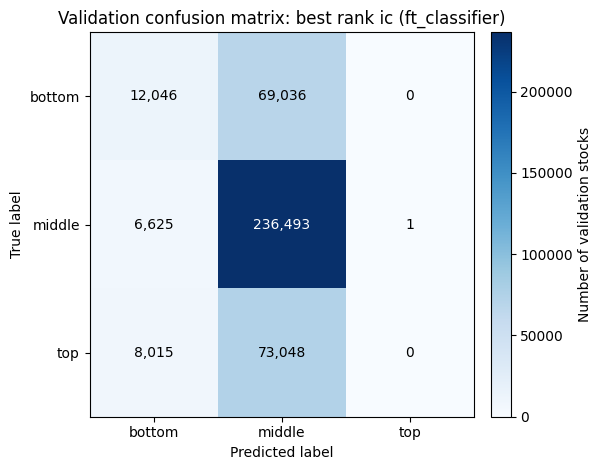

best_annualized_return: mlp_er_train


,bottom,middle,top
bottom,7148,73910,24
middle,3578,239531,10
top,4486,76567,10


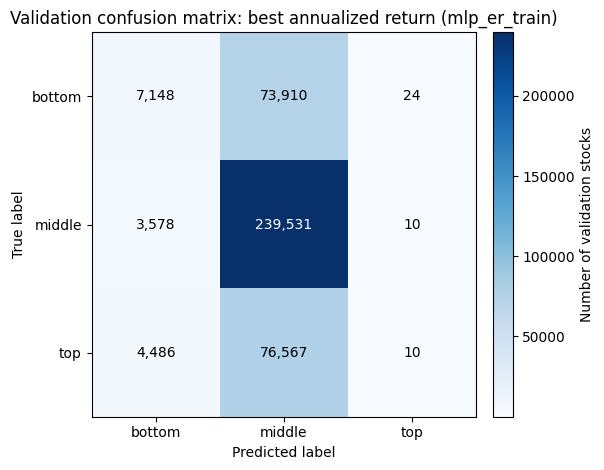

,score_label,classifier_prefix,validation_rows,accuracy,selection
0,ft_classifier,ft,405264,0.613277,best_rank_ic
1,mlp_er_train,mlp,405264,0.608712,best_annualized_return


In [28]:
# Cell 18b: Validation confusion-matrix heatmaps for best Rank IC and best annualized-return models

CLASS_LABELS = ["bottom", "middle", "top"]


def classifier_prefix_from_score_label(score_label: str) -> str | None:
    for prefix in ["mlp", "ft", "xgb", "temporal"]:
        if score_label == f"{prefix}_classifier" or score_label.startswith(f"{prefix}_"):
            prob_cols = [f"prob_{prefix}_bottom", f"prob_{prefix}_middle", f"prob_{prefix}_top"]
            if all(col in work.columns for col in prob_cols):
                return prefix
    return None


def validation_confusion_matrix_for_score(score_label: str) -> tuple[pd.DataFrame, pd.Series]:
    prefix = classifier_prefix_from_score_label(score_label)
    if prefix is None:
        raise ValueError(f"No classifier probability columns are available for score label: {score_label}")

    prob_cols = [f"prob_{prefix}_bottom", f"prob_{prefix}_middle", f"prob_{prefix}_top"]
    validation = work.loc[work["split"].eq("validation"), ["top_bottom_label"] + prob_cols].dropna().copy()
    validation["predicted_label"] = np.argmax(validation[prob_cols].to_numpy(dtype="float64"), axis=1)

    # Rows are the true realized class; columns are the model-predicted class.
    matrix = pd.crosstab(
        validation["top_bottom_label"],
        validation["predicted_label"],
        rownames=["True label"],
        colnames=["Predicted label"],
        dropna=False,
    ).reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
    matrix.index = CLASS_LABELS
    matrix.columns = CLASS_LABELS

    total = matrix.to_numpy().sum()
    summary = pd.Series(
        {
            "score_label": score_label,
            "classifier_prefix": prefix,
            "validation_rows": int(total),
            "accuracy": float(np.trace(matrix.to_numpy()) / total) if total else np.nan,
        }
    )
    return matrix, summary


def plot_confusion_heatmap(matrix: pd.DataFrame, title: str, path: Path | None = None) -> None:
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    values = matrix.to_numpy(dtype="float64")
    image = ax.imshow(values, cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Number of validation stocks")

    ax.set_xticks(np.arange(len(CLASS_LABELS)))
    ax.set_yticks(np.arange(len(CLASS_LABELS)))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    threshold = values.max() / 2 if values.size and values.max() > 0 else 0
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            color = "white" if values[row, col] > threshold else "black"
            ax.text(col, row, f"{int(values[row, col]):,}", ha="center", va="center", color=color, fontsize=10)

    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


best_rank_ic_label = validation_rank_ic.sort_values("mean_rank_ic", ascending=False).iloc[0]["score_label"]
best_annualized_return_label = (
    validation_portfolios
    .sort_values(["annualized_return", "sharpe"], ascending=False)
    .iloc[0]["score_label"]
)

confusion_outputs = []
for selection_name, score_label in [
    ("best_rank_ic", best_rank_ic_label),
    ("best_annualized_return", best_annualized_return_label),
]:
    matrix, summary = validation_confusion_matrix_for_score(score_label)
    summary["selection"] = selection_name
    confusion_outputs.append(summary)
    print(f"{selection_name}: {score_label}")
    display(matrix)
    matrix.to_csv(BACKTEST_DIR / f"validation_confusion_matrix_{selection_name}.csv")
    plot_confusion_heatmap(
        matrix,
        title=f"Validation confusion matrix: {selection_name.replace('_', ' ')} ({score_label})",
        path=FIGURE_DIR / f"validation_confusion_matrix_{selection_name}.png",
    )

confusion_matrix_summary = pd.DataFrame(confusion_outputs)
confusion_matrix_summary.to_csv(BACKTEST_DIR / "validation_confusion_matrix_summary.csv", index=False)
confusion_matrix_summary


In [29]:
# Cell 19: Choose the specification using validation only

SELECTION_COST_BPS = 10.0

selection_table = (
    validation_portfolios
    .loc[validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS) & validation_portfolios["eligible_for_selection"]]
    .sort_values(
        ["validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

if selection_table.empty:
    raise ValueError("No validation strategy rows found. Check candidate_score_labels and score_columns.")

display(selection_table[VALIDATION_RANKING_COLUMNS].head(30))

chosen_spec = selection_table.iloc[0][["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]].to_dict()
chosen_spec


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,mlp_er_train,long_short,0.2,True,0.01,10.0,-0.211304,0.039678,1.428230,0.354393,0.248134,1.785470,True,1351.516667,52.450000,1.983333,0.007557,0.022602,0.022602,-0.161748
1,mlp_er_train,long_short,0.2,True,0.02,10.0,-0.702876,0.039678,1.145626,0.329658,0.287753,1.930084,True,679.883333,12.900000,1.733333,0.009247,0.027404,0.027404,-0.253852
2,xgb_er_train,long_short,0.2,True,0.01,10.0,-0.430426,0.053725,1.193829,0.266753,0.223443,1.721290,True,1351.516667,164.216667,2.000000,0.009576,0.014185,0.014185,-0.245680
3,xgb_er_train,long_short,0.2,True,0.02,10.0,-2.169319,0.053725,0.451868,0.218124,0.482717,2.410318,True,935.300000,23.150000,1.883333,0.008672,0.027349,0.027349,-0.368201
4,ft_er_train,long_short,0.2,True,0.01,10.0,-1.344412,0.086685,0.496410,0.186920,0.376544,1.737883,True,1351.516667,18.283333,2.000000,0.010367,0.013022,0.013022,-0.575093
5,xgb_er_train,long_short,0.2,True,0.00,10.0,-0.061482,0.053725,1.244420,0.174003,0.139827,1.393803,True,1351.516667,572.116667,2.000000,0.009576,0.006077,0.006077,-0.147648
6,mlp_er_train,long_short,0.2,True,0.00,10.0,-0.708942,0.039678,1.042079,0.173302,0.166305,1.797696,True,1351.516667,247.100000,2.000000,0.007557,0.008844,0.008844,-0.201399
7,ft_er_train,long_short,0.2,True,0.00,10.0,-0.011061,0.086685,0.982666,0.166783,0.169725,1.077470,True,1351.516667,467.483333,2.000000,0.010367,0.004859,0.004859,-0.164535
8,ft_er_train,long_short_130_30,0.2,False,0.00,10.0,0.489458,0.086685,1.109196,0.159942,0.144196,0.722169,True,1351.516667,1350.516667,1.600000,0.010367,0.001789,0.000537,-0.202022
9,ft_classifier,long_short_130_30,0.2,False,0.00,10.0,0.748948,0.093598,1.335990,0.152062,0.113820,0.718882,True,1351.516667,1350.516667,1.600000,0.009775,0.001357,0.000407,-0.121742


{'score_label': 'mlp_er_train',
 'rule': 'long_short',
 'q': 0.2,
 'sign_gate': False,
 'threshold_gate': True,
 'zero_threshold': 0.01,
 'one_way_cost_bps': 10.0}

In [30]:
# Cell 20: Test performance for the fixed validation choice

chosen_test = portfolio_summary.loc[
    portfolio_summary["split"].eq("test")
    & portfolio_summary["score_label"].eq(chosen_spec["score_label"])
    & portfolio_summary["rule"].eq(chosen_spec["rule"])
    & portfolio_summary["q"].eq(chosen_spec["q"])
    & portfolio_summary["sign_gate"].eq(chosen_spec["sign_gate"])
    & portfolio_summary["threshold_gate"].eq(chosen_spec["threshold_gate"])
    & portfolio_summary["zero_threshold"].eq(chosen_spec["zero_threshold"])
    & portfolio_summary["one_way_cost_bps"].eq(chosen_spec["one_way_cost_bps"])
].reset_index(drop=True)

assert len(chosen_test) == 1, "Expected exactly one test row for the chosen specification."
chosen_test


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,mlp_er_train,long_short,0.2,False,True,0.01,10.0,test,107,0.212737,0.251756,0.845014,-0.615299,0.018887,0.072676,1.512874,2.0,1.244097e-17,1.0,1.0,1624.757009,274.504673,0.012062,0.008338,0.008338,0.234695,0.251587,0.93286,-0.605101,0.0204,0.072627


Top 5 eligible validation specifications by composite score at 10 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
103,ft_er_train,gross_normalized_long_short,0.2,False,0.0,10.0,0.836249,0.086685,1.149689,0.068329,0.059433,0.409021,True,1351.516667,1350.516667,1.0,0.010367,0.001789,0.000894,-0.060333
69,ft_classifier,long_short_130_30,0.2,False,0.0,10.0,0.748948,0.093598,1.335990,0.152062,0.113820,0.718882,True,1351.516667,1350.516667,1.6,0.009775,0.001357,0.000407,-0.121742
105,ft_classifier,gross_normalized_long_short,0.2,False,0.0,10.0,0.556413,0.093598,0.863369,0.061267,0.070962,0.390858,True,1351.516667,1350.516667,1.0,0.009775,0.001357,0.000678,-0.098359
79,ft_classifier,long_only,0.2,False,0.0,10.0,0.545485,0.093598,0.942915,0.110004,0.116663,0.484368,True,1351.516667,0.000000,1.0,0.009775,NaN,NaN,-0.174372
109,xgb_er_train,gross_normalized_long_short,0.2,False,0.0,10.0,0.522439,0.053725,1.092549,0.055519,0.050816,0.628537,True,1351.516667,1350.516667,1.0,0.009576,0.000917,0.000459,-0.054569


Top 5 eligible validation specifications by net annualized return at 10 bps, plus requested MLP spec if absent


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
60,mlp_er_train,long_short,0.2,True,0.01,10.0,-0.211304,0.039678,1.428230,0.354393,0.248134,1.785470,True,1351.516667,52.450000,1.983333,0.007557,0.022602,0.022602,-0.161748
61,mlp_er_train,long_short,0.2,True,0.02,10.0,-0.702876,0.039678,1.145626,0.329658,0.287753,1.930084,True,679.883333,12.900000,1.733333,0.009247,0.027404,0.027404,-0.253852
62,xgb_er_train,long_short,0.2,True,0.01,10.0,-0.430426,0.053725,1.193829,0.266753,0.223443,1.721290,True,1351.516667,164.216667,2.000000,0.009576,0.014185,0.014185,-0.245680
63,xgb_er_train,long_short,0.2,True,0.02,10.0,-2.169319,0.053725,0.451868,0.218124,0.482717,2.410318,True,935.300000,23.150000,1.883333,0.008672,0.027349,0.027349,-0.368201
64,ft_er_train,long_short,0.2,True,0.01,10.0,-1.344412,0.086685,0.496410,0.186920,0.376544,1.737883,True,1351.516667,18.283333,2.000000,0.010367,0.013022,0.013022,-0.575093


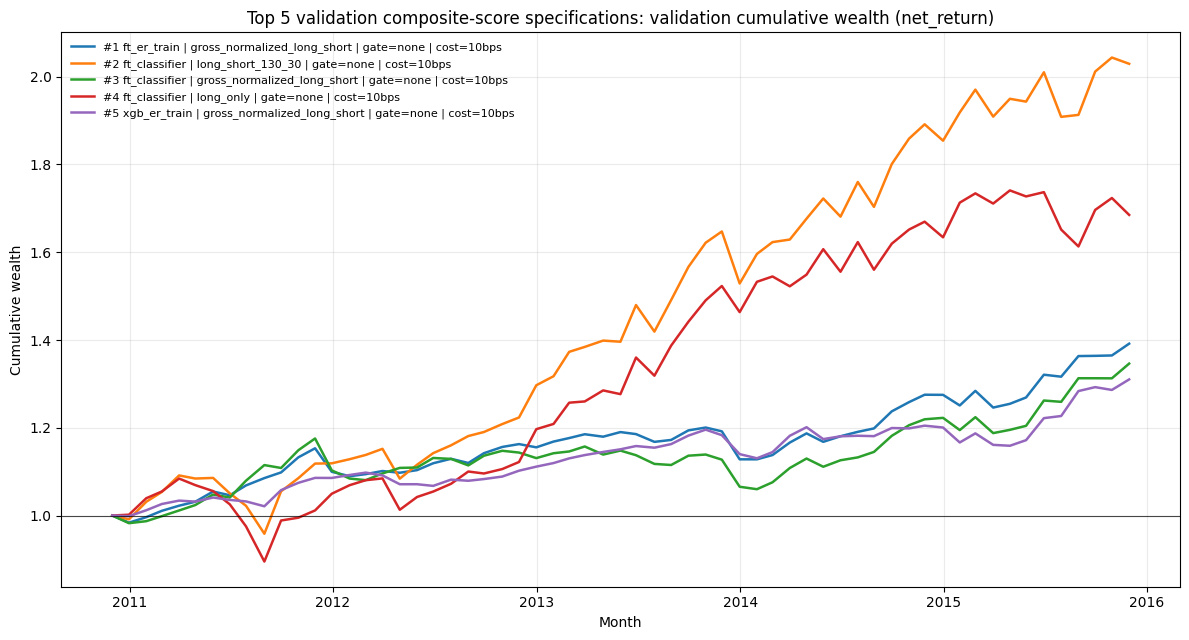

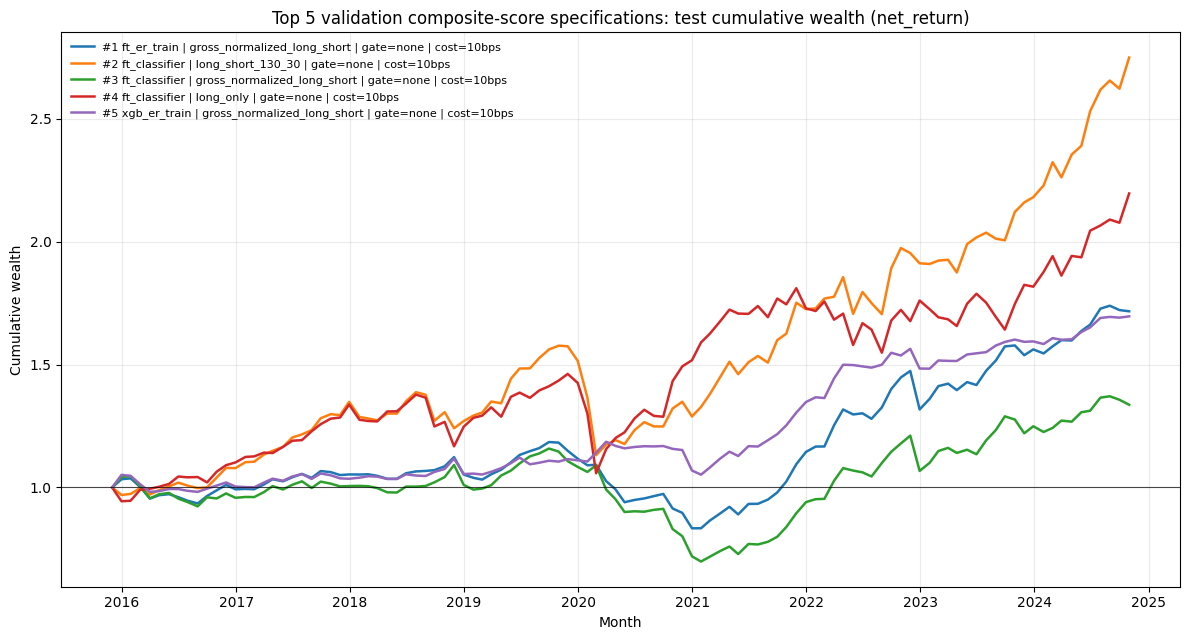

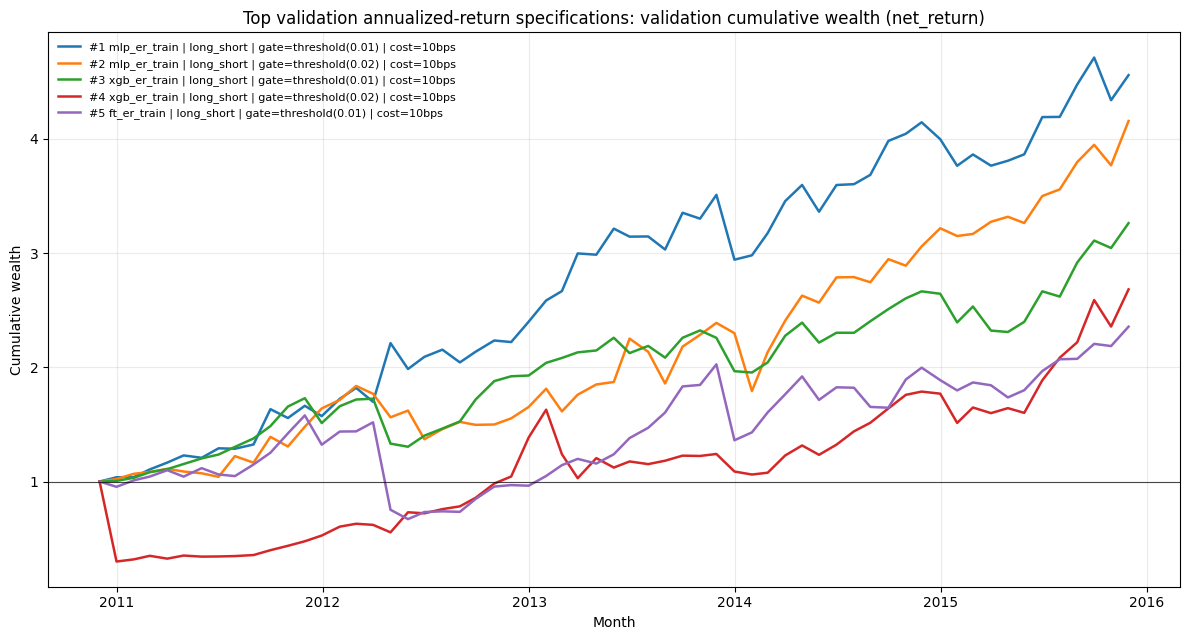

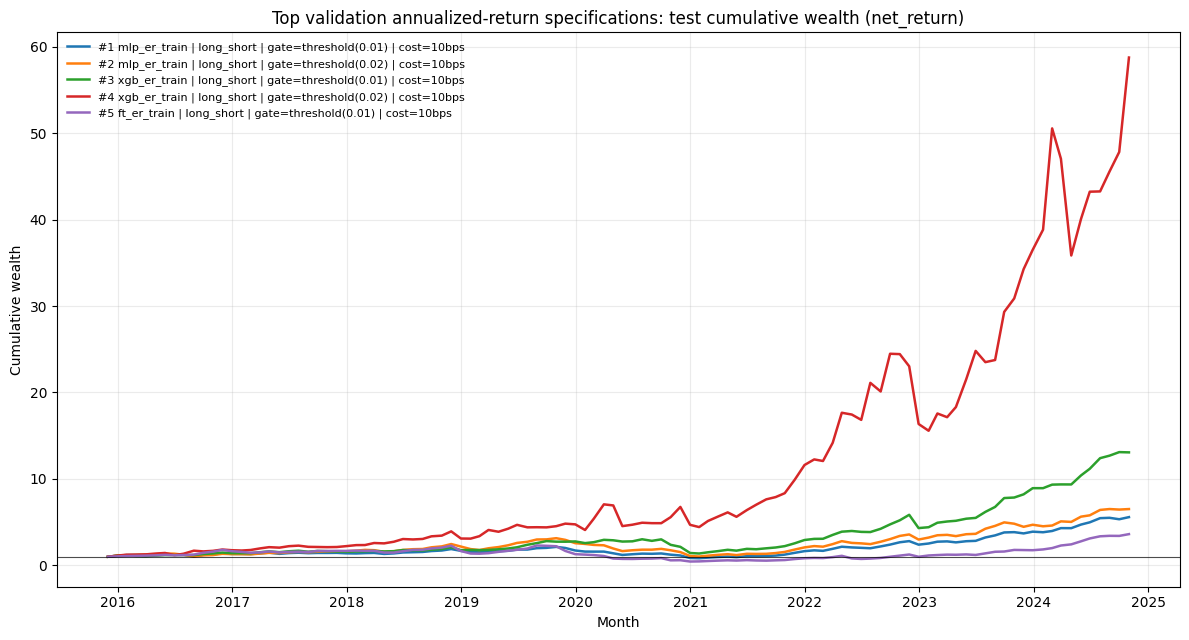

In [31]:
# Cell 21: Plot cumulative wealth for top validation specifications

SPEC_COLUMNS = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]


def spec_mask(monthly: pd.DataFrame, spec: pd.Series) -> pd.Series:
    return (
        monthly["split"].eq(spec["split_to_plot"])
        & monthly["score_label"].eq(spec["score_label"])
        & monthly["rule"].eq(spec["rule"])
        & np.isclose(monthly["q"].astype(float), float(spec["q"]))
        & monthly["sign_gate"].eq(bool(spec["sign_gate"]))
        & monthly["threshold_gate"].eq(bool(spec["threshold_gate"]))
        & np.isclose(monthly["zero_threshold"].astype(float), float(spec["zero_threshold"]))
        & np.isclose(monthly["one_way_cost_bps"].astype(float), float(spec["one_way_cost_bps"]))
    )


def plot_cumulative_wealth(
    monthly: pd.DataFrame,
    specs: pd.DataFrame,
    split: str,
    title_prefix: str,
    return_col: str = "net_return",
    path: Path | None = None,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 6.5))
    plotted = 0
    specs = specs.copy()
    specs["split_to_plot"] = split

    for rank, (_, spec) in enumerate(specs.iterrows(), start=1):
        part = monthly.loc[spec_mask(monthly, spec)].sort_values("month")
        if part.empty:
            print(f"Skipping missing series for {split}: {spec[SPEC_COLUMNS].to_dict()}")
            continue

        month_index = pd.to_datetime(part["month"].to_numpy())
        monthly_returns = pd.Series(part[return_col].fillna(0.0).to_numpy(dtype="float64"), index=month_index)
        start_month = month_index[0] - pd.offsets.MonthBegin(1)
        wealth = pd.concat([pd.Series([1.0], index=[start_month]), (1.0 + monthly_returns).cumprod()])

        gate_label = "threshold" if spec["threshold_gate"] else ("sign" if spec["sign_gate"] else "none")
        if spec["threshold_gate"]:
            gate_label = f"threshold({spec['zero_threshold']:.2f})"
        label = (
            f"#{rank} {spec['score_label']} | {spec['rule']} | "
            f"gate={gate_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        )
        ax.plot(wealth.index, wealth.values, linewidth=1.8, label=label)
        plotted += 1

    if plotted == 0:
        raise ValueError(f"No cumulative-wealth series found for split={split!r}.")

    ax.axhline(1.0, linewidth=0.8, color="black", alpha=0.7)
    ax.set_title(f"{title_prefix}: {split} cumulative wealth ({return_col})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def add_required_spec_if_missing(specs: pd.DataFrame, candidates: pd.DataFrame) -> pd.DataFrame:
    required = candidates.loc[
        candidates["score_label"].eq("mlp_er_train")
        & candidates["rule"].eq("long_short")
        & candidates["threshold_gate"].eq(True)
        & np.isclose(candidates["zero_threshold"].astype(float), 0.01)
        & candidates["one_way_cost_bps"].eq(SELECTION_COST_BPS)
    ].sort_values(["validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False])

    if required.empty:
        print("Requested mlp_er_train long_short threshold(0.01) spec was not found at the selection cost.")
        return specs

    required_row = required.head(1)
    key_cols = SPEC_COLUMNS
    already_present = specs[key_cols].merge(required_row[key_cols], on=key_cols, how="inner").shape[0] > 0
    if already_present:
        return specs
    return pd.concat([specs, required_row], ignore_index=True)


eligible_selection_pool = validation_portfolios.loc[
    validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS)
    & validation_portfolios["eligible_for_selection"]
].copy()

top5_composite_specs = (
    eligible_selection_pool
    .sort_values(["validation_composite_score", "validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False, False])
    .head(5)
    .copy()
)

top5_annual_return_specs = (
    eligible_selection_pool
    .sort_values(["validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"], ascending=[False, False, False])
    .head(5)
    .copy()
)
top5_annual_return_specs = add_required_spec_if_missing(top5_annual_return_specs, eligible_selection_pool)

print(f"Top 5 eligible validation specifications by composite score at {SELECTION_COST_BPS:.0f} bps")
display(top5_composite_specs[VALIDATION_RANKING_COLUMNS])
print(f"Top 5 eligible validation specifications by net annualized return at {SELECTION_COST_BPS:.0f} bps, plus requested MLP spec if absent")
display(top5_annual_return_specs[VALIDATION_RANKING_COLUMNS])

plot_cumulative_wealth(
    portfolio_monthly,
    top5_composite_specs,
    split="validation",
    title_prefix="Top 5 validation composite-score specifications",
    return_col="net_return",
    path=FIGURE_DIR / "validation_top5_composite_dl_xgb_strategy_cumulative_wealth.png",
)
plot_cumulative_wealth(
    portfolio_monthly,
    top5_composite_specs,
    split="test",
    title_prefix="Top 5 validation composite-score specifications",
    return_col="net_return",
    path=FIGURE_DIR / "test_top5_composite_dl_xgb_strategy_cumulative_wealth.png",
)
plot_cumulative_wealth(
    portfolio_monthly,
    top5_annual_return_specs,
    split="validation",
    title_prefix="Top validation annualized-return specifications",
    return_col="net_return",
    path=FIGURE_DIR / "validation_top5_annual_return_dl_xgb_strategy_cumulative_wealth.png",
)
plot_cumulative_wealth(
    portfolio_monthly,
    top5_annual_return_specs,
    split="test",
    title_prefix="Top validation annualized-return specifications",
    return_col="net_return",
    path=FIGURE_DIR / "test_top5_annual_return_dl_xgb_strategy_cumulative_wealth.png",
)


In [32]:
# Cell 22: Save compact report tables

validation_rank_ic.to_csv(BACKTEST_DIR / "validation_dl_xgb_score_rank_ic_ranking.csv", index=False)
validation_portfolios.to_csv(BACKTEST_DIR / "validation_dl_xgb_score_strategy_ranking.csv", index=False)
selection_table.to_csv(BACKTEST_DIR / "validation_dl_xgb_selection_table_10bps.csv", index=False)

for cost_bps, ranking in validation_rankings_by_cost.items():
    ranking.to_csv(BACKTEST_DIR / f"validation_dl_xgb_score_strategy_ranking_{int(cost_bps)}bps.csv", index=False)

pd.DataFrame([chosen_spec]).to_csv(BACKTEST_DIR / "chosen_validation_dl_xgb_specification.csv", index=False)
chosen_test.to_csv(BACKTEST_DIR / "test_performance_of_chosen_validation_dl_xgb_spec.csv", index=False)

print("Saved outputs to:")
print("Predictions:", PREDICTION_OUTPUT)
print("Tables:", TABLE_DIR)
print("Backtests:", BACKTEST_DIR)
print("Figures:", FIGURE_DIR)


Saved outputs to:
Predictions: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/dl_xgb_predictions.parquet
Tables: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/tables
Backtests: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/dl_xgb_score_strategies
Figures: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/dl_xgb_score_strategies/figures


In [33]:
# Cell 23: Optional sanity table: validation score correlations


def score_correlation_table(data: pd.DataFrame, score_columns: dict, split: str = "validation") -> pd.DataFrame:
    cols = [col for col in score_columns.values() if col in data.columns]
    labels = {v: k for k, v in score_columns.items()}
    part = data.loc[data["split"].eq(split), cols].copy()
    corr = part.corr(method="spearman")
    return corr.rename(index=labels, columns=labels)


validation_score_corr = score_correlation_table(work, score_columns, split="validation")
validation_score_corr.to_csv(BACKTEST_DIR / "validation_dl_xgb_score_spearman_correlation.csv")
validation_score_corr


,mlp_regressor,xgb_regressor,mlp_classifier,mlp_er_train,ft_classifier,ft_er_train,xgb_classifier,xgb_er_train,mlp_hybrid_alpha_0.25,mlp_hybrid_alpha_0.50,mlp_hybrid_alpha_0.75,mlp_hybrid_alpha_0.90,mlp_er_pred_return_buckets,mlp_er_pred_classifier_buckets,xgb_hybrid_alpha_0.25,xgb_hybrid_alpha_0.50,xgb_hybrid_alpha_0.75,xgb_hybrid_alpha_0.90,xgb_er_pred_return_buckets,xgb_er_pred_classifier_buckets
mlp_regressor,1.000000,0.552387,-0.155371,-0.095029,0.038336,0.059881,-0.064816,-0.025746,0.265188,0.259937,0.243716,0.193252,0.928039,0.928044,0.026040,0.024043,0.018236,0.001625,0.546387,0.546103
xgb_regressor,0.552387,1.000000,-0.162736,-0.080954,0.020412,0.059730,-0.092765,-0.044392,0.006702,0.003188,-0.006776,-0.032491,0.572340,0.570996,0.125892,0.121529,0.107921,0.066617,0.951031,0.950596
mlp_classifier,-0.155371,-0.162736,1.000000,0.764590,0.626695,0.636147,0.697229,0.564154,0.297043,0.318443,0.379580,0.534411,-0.208522,-0.227757,0.320259,0.339879,0.392342,0.504243,-0.204626,-0.219463
mlp_er_train,-0.095029,-0.080954,0.764590,1.000000,0.212560,0.557646,0.500563,0.637145,0.276556,0.294406,0.345137,0.471090,-0.157964,-0.175079,0.327751,0.340681,0.374490,0.441403,-0.140525,-0.148868
ft_classifier,0.038336,0.020412,0.626695,0.212560,1.000000,0.742830,0.580179,0.311801,0.183393,0.196606,0.234403,0.330595,0.013441,0.000837,0.203455,0.221209,0.269252,0.374587,-0.001116,-0.017820
ft_er_train,0.059881,0.059730,0.636147,0.557646,0.742830,1.000000,0.622103,0.582594,0.191768,0.205629,0.245325,0.346308,0.018088,0.003350,0.244996,0.263572,0.313933,0.424231,0.021675,0.005232
xgb_classifier,-0.064816,-0.092765,0.697229,0.500563,0.580179,0.622103,1.000000,0.881081,0.352765,0.366401,0.404856,0.498665,-0.144405,-0.157403,0.431081,0.460112,0.537982,0.704413,-0.153997,-0.172966
xgb_er_train,-0.025746,-0.044392,0.564154,0.637145,0.311801,0.582594,0.881081,1.000000,0.332249,0.343442,0.374810,0.449669,-0.109005,-0.120152,0.445411,0.471067,0.539305,0.681430,-0.118528,-0.134336
mlp_hybrid_alpha_0.25,0.265188,0.006702,0.297043,0.276556,0.183393,0.191768,0.352765,0.332249,1.000000,0.999603,0.994029,0.949597,-0.042234,-0.042655,0.309397,0.317222,0.336572,0.368905,-0.051513,-0.054430
mlp_hybrid_alpha_0.50,0.259937,0.003188,0.318443,0.294406,0.196606,0.205629,0.366401,0.343442,0.999603,1.000000,0.996695,0.957691,-0.046469,-0.047362,0.315529,0.323756,0.344178,0.378769,-0.055894,-0.059115


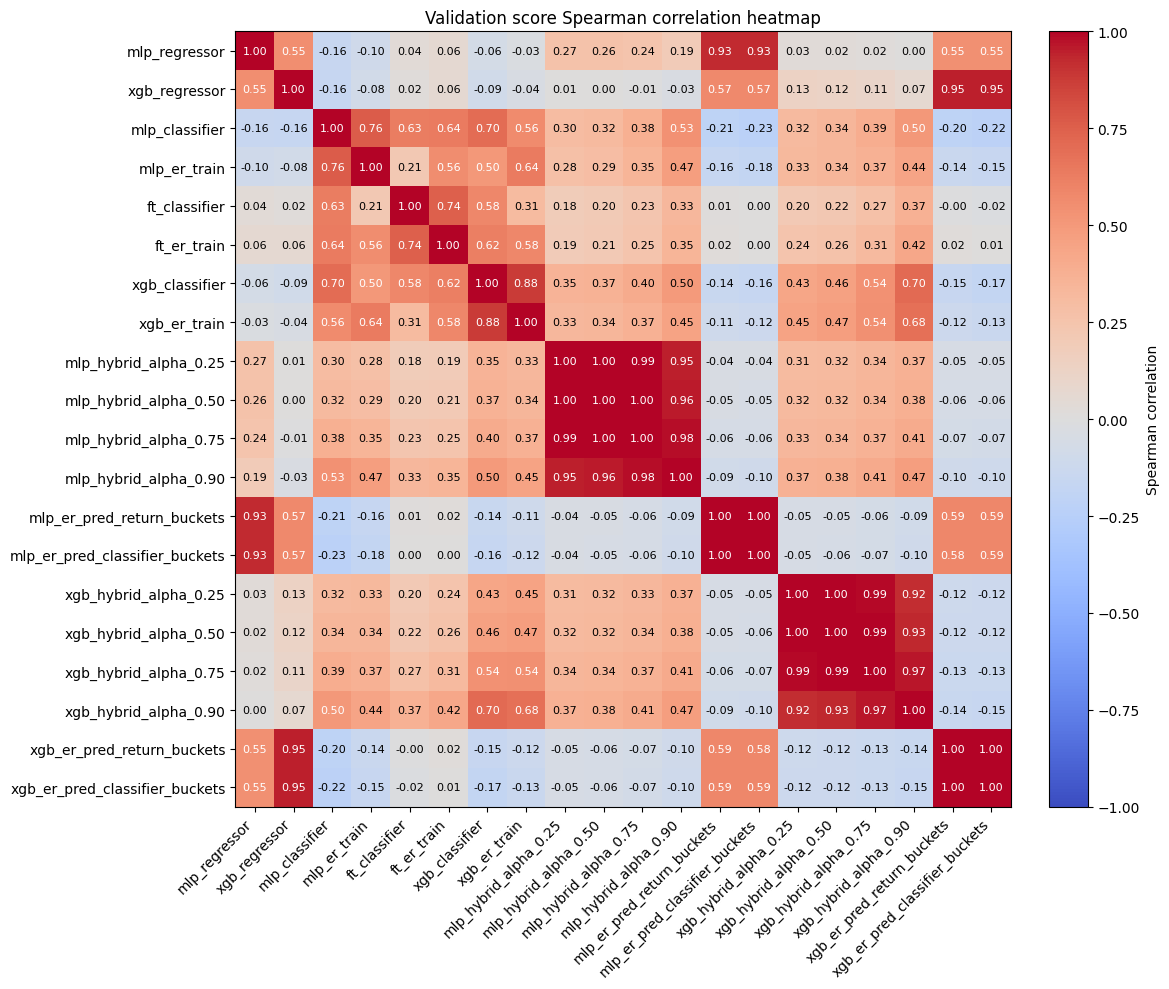

In [34]:
# Cell 24: Validation score-correlation heatmap

if not validation_score_corr.empty:
    fig, ax = plt.subplots(figsize=(12, 10))
    heatmap_values = validation_score_corr.to_numpy(dtype=float)
    image = ax.imshow(heatmap_values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(validation_score_corr.columns)))
    ax.set_yticks(range(len(validation_score_corr.index)))
    ax.set_xticklabels(validation_score_corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(validation_score_corr.index)
    ax.set_title("Validation score Spearman correlation heatmap")

    for i in range(validation_score_corr.shape[0]):
        for j in range(validation_score_corr.shape[1]):
            value = heatmap_values[i, j]
            color = "white" if abs(value) > 0.5 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "validation_dl_xgb_score_spearman_correlation_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()


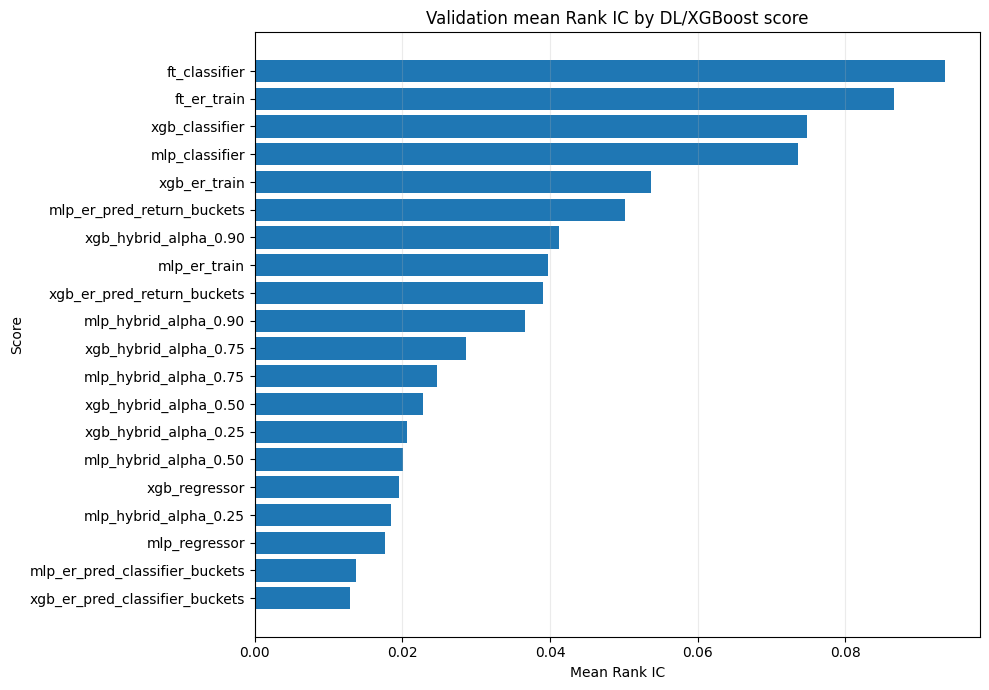

In [35]:
# Cell 25: Rank IC bar chart

rank_ic_plot = validation_rank_ic.sort_values("mean_rank_ic", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(rank_ic_plot))))
ax.barh(rank_ic_plot["score_label"], rank_ic_plot["mean_rank_ic"])
ax.set_title("Validation mean Rank IC by DL/XGBoost score")
ax.set_xlabel("Mean Rank IC")
ax.set_ylabel("Score")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_dl_xgb_score_rank_ic_bar_chart.png", dpi=160, bbox_inches="tight")
plt.show()
